# Lab 4. Probability and Language

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-04-probability-and-language.ipynb)

This lab accompanies Chapter 4 of **Mathematical Natural Language Processing**.

In the previous labs, text became tokens, vocabularies, and vectors. In this lab, we add the probabilistic viewpoint:

$$
\text{text data} \quad \longrightarrow \quad \text{random tokens, probability distributions, and likelihoods}.
$$

The central idea is that a language model assigns probabilities to tokens or token sequences. A modern next-token model estimates a conditional distribution

$$
p(w_t \mid w_1,\ldots,w_{t-1}).
$$

This notebook is designed for independent study. It includes the mathematical background before programming, guided examples, exercises, and a mini-project.

## How to use this lab

1. Read each mathematical explanation before running the code.
2. Run the code cells in order.
3. Inspect the tables and plots carefully.
4. When you see **Try it yourself**, modify the code and rerun the cell.
5. Complete the exercises and mini-project at the end.

The lab uses only standard Python scientific tools: `numpy`, `pandas`, and `matplotlib`. It should run directly in Google Colab.

## Learning goals

After completing this lab, you should be able to:

- model a token as a random variable over a finite vocabulary;
- turn token counts into an empirical probability distribution;
- verify that a probability vector lies in the simplex;
- compute likelihood, log-likelihood, negative log-likelihood, and perplexity;
- compute entropy, cross-entropy, and KL divergence;
- explain why the unigram maximum likelihood estimator is the empirical frequency;
- build conditional next-token distributions from bigram counts;
- apply add-alpha smoothing to avoid zero probabilities;
- use softmax temperature to control next-token uncertainty;
- implement a tiny Bayesian text classifier using log probabilities.

## 1. Mathematical background: tokens as random variables

Let

$$
V=\{v_1,v_2,\ldots,v_d\}
$$

be a finite vocabulary. A single token can be modeled as a random variable $W$ taking values in $V$.

A probability distribution over $V$ is a vector

$$
p=(p_1,p_2,\ldots,p_d)
$$

such that

$$
p_j \geq 0, \qquad \sum_{j=1}^d p_j=1.
$$

The set of all such vectors is the probability simplex.

For a token sequence

$$
w_{1:T}=(w_1,w_2,\ldots,w_T),
$$

a language model assigns a probability

$$
p(w_{1:T}).
$$

By the chain rule,

$$
p(w_{1:T})=\prod_{t=1}^T p(w_t \mid w_1,\ldots,w_{t-1}).
$$

This exact identity is the mathematical foundation of next-token prediction.

## 2. Setup

We import tools for text processing, counting, arrays, tables, and plots.

In [1]:
import re
import math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_columns", 40)

rng = np.random.default_rng(7243)

## 3. A small corpus

We use a small mathematical NLP corpus so that we can inspect every probability by hand.

The corpus is intentionally tiny. In a real NLP system, the corpus may contain millions or billions of tokens. The formulas are the same; only the scale changes.

In [2]:
corpus = [
    "Language models assign probabilities to token sequences.",
    "Probability helps models represent uncertainty in language.",
    "A token distribution assigns mass to each vocabulary item.",
    "Entropy measures uncertainty in a probability distribution.",
    "Cross entropy measures how surprised a model is by data.",
    "Perplexity exponentiates average negative log likelihood.",
    "Bigram models estimate the next token from the previous token.",
    "Smoothing gives nonzero probability to unseen token pairs.",
    "Bayesian classifiers combine priors with likelihoods.",
    "Generative models describe how text and labels arise together.",
    "Discriminative models estimate labels directly from text.",
    "Language modeling is conditional probability estimation."
]

def tokenize(text):
    # Lowercase tokenization that keeps alphabetic words.
    return re.findall(r"[a-z]+", text.lower())

tokenized_docs = [tokenize(doc) for doc in corpus]
tokens = [tok for doc in tokenized_docs for tok in doc]

print("Number of documents:", len(corpus))
print("Number of tokens:", len(tokens))
print("First document tokens:", tokenized_docs[0])

Number of documents: 12
Number of tokens: 92
First document tokens: ['language', 'models', 'assign', 'probabilities', 'to', 'token', 'sequences']


## 4. Empirical token probabilities

Suppose token $v_j$ appears $c_j$ times in a corpus. Let

$$
N=\sum_{j=1}^d c_j
$$

be the total number of tokens. The empirical probability of $v_j$ is

$$
\widehat p_j=\frac{c_j}{N}.
$$

This is the simplest probability estimator in NLP.

In [3]:
counts = Counter(tokens)
N = sum(counts.values())
vocab = sorted(counts)

empirical_p = {tok: counts[tok] / N for tok in vocab}

prob_table = pd.DataFrame({
    "token": vocab,
    "count": [counts[tok] for tok in vocab],
    "empirical_probability": [empirical_p[tok] for tok in vocab]
}).sort_values(["count", "token"], ascending=[False, True]).reset_index(drop=True)

prob_table.head(15)

,token,count,empirical_probability
0,models,5,0.054348
1,token,5,0.054348
2,probability,4,0.043478
3,a,3,0.032609
4,language,3,0.032609
5,to,3,0.032609
6,distribution,2,0.021739
7,entropy,2,0.021739
8,estimate,2,0.021739
9,from,2,0.021739


### Check the simplex conditions

A probability vector must satisfy two conditions:

$$
p_j\geq 0 \quad \text{for every } j,
$$

and

$$
\sum_j p_j=1.
$$

Let us verify these conditions numerically.

In [4]:
p_vec = np.array([empirical_p[tok] for tok in vocab])

print("Vocabulary size d:", len(vocab))
print("All probabilities nonnegative?", bool(np.all(p_vec >= 0)))
print("Sum of probabilities:", p_vec.sum())
print("Close to 1?", np.isclose(p_vec.sum(), 1.0))

Vocabulary size d: 63
All probabilities nonnegative? True
Sum of probabilities: 1.0000000000000002
Close to 1? True


### Plot the most common tokens

A probability distribution over words is usually not uniform. Some tokens occur much more often than others.

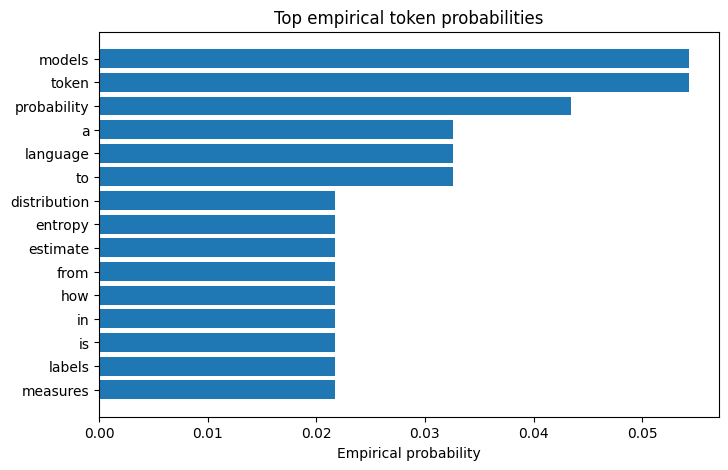

In [5]:
top = prob_table.head(15).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(top["token"], top["empirical_probability"])
plt.xlabel("Empirical probability")
plt.title("Top empirical token probabilities")
plt.show()

**Try it yourself.** Add two new sentences to the corpus, rerun the cells above, and observe how the empirical distribution changes.

## 5. A reusable empirical distribution function

It is useful to write small functions that turn tokens into counts and probabilities.

In [6]:
def empirical_distribution(items):
    # Return counts and empirical probabilities for a finite sample.
    counts = Counter(items)
    total = sum(counts.values())
    if total == 0:
        raise ValueError("Cannot build a distribution from an empty sample.")
    probs = {item: count / total for item, count in counts.items()}
    return counts, probs

example_tokens = tokenize("models learn from data and models learn from language")
ex_counts, ex_probs = empirical_distribution(example_tokens)

pd.DataFrame({
    "token": sorted(ex_probs),
    "count": [ex_counts[t] for t in sorted(ex_probs)],
    "probability": [ex_probs[t] for t in sorted(ex_probs)]
})

,token,count,probability
0,and,1,0.111111
1,data,1,0.111111
2,from,2,0.222222
3,language,1,0.111111
4,learn,2,0.222222
5,models,2,0.222222


## 6. Likelihood and log-likelihood for a unigram model

A unigram model assumes that tokens are independent draws from a vocabulary distribution $q$.

For observed tokens $w_1,\ldots,w_N$, the likelihood is

$$
L(q)=\prod_{i=1}^N q(w_i).
$$

Using counts, this can be written as

$$
L(q)=\prod_{j=1}^d q_j^{c_j}.
$$

The log-likelihood is

$$
\ell(q)=\sum_{j=1}^d c_j\log q_j.
$$

For long text, log-likelihood is preferred because products of many probabilities become extremely small.

In [7]:
def log_likelihood_from_counts(counts, probs, epsilon=1e-15):
    # Log-likelihood sum_j c_j log q_j.
    # epsilon prevents log(0) when a model assigns zero probability.
    total = 0.0
    for tok, c in counts.items():
        q = max(probs.get(tok, 0.0), epsilon)
        total += c * math.log(q)
    return total

def negative_log_likelihood_from_counts(counts, probs):
    return -log_likelihood_from_counts(counts, probs)

# Candidate unigram models on the same vocabulary
uniform_q = {tok: 1 / len(vocab) for tok in vocab}
empirical_q = empirical_p.copy()

# A hand-made model that gives extra mass to a few NLP words, then renormalizes.
hand_scores = {tok: 1.0 for tok in vocab}
for tok in ["language", "models", "probability", "token", "entropy"]:
    if tok in hand_scores:
        hand_scores[tok] = 5.0
score_total = sum(hand_scores.values())
hand_q = {tok: score / score_total for tok, score in hand_scores.items()}

model_rows = []
for name, q in [("empirical MLE", empirical_q), ("uniform", uniform_q), ("hand-made", hand_q)]:
    ll = log_likelihood_from_counts(counts, q)
    nll = -ll
    avg_nll = nll / N
    ppl = math.exp(avg_nll)
    model_rows.append({
        "model": name,
        "log_likelihood": ll,
        "negative_log_likelihood": nll,
        "avg_nll": avg_nll,
        "perplexity": ppl
    })

pd.DataFrame(model_rows).sort_values("avg_nll")

,model,log_likelihood,negative_log_likelihood,avg_nll,perplexity
0,empirical MLE,-367.841950,367.841950,3.998282,54.504434
2,hand-made,-375.954016,375.954016,4.086457,59.528589
1,uniform,-381.168395,381.168395,4.143135,63.000000


### Interpretation

The empirical distribution has the best unigram likelihood on the same data used to estimate it. This is not an accident. Under the unigram model, the maximum likelihood estimator is

$$
\widehat p_j=\frac{c_j}{N}.
$$

This means that empirical frequency is not merely a counting trick. It is the solution to a statistical optimization problem.

## 7. Visualizing a simple maximum likelihood problem

To see maximum likelihood in one dimension, reduce the vocabulary to two outcomes:

- outcome 1: the token is `model` or `models`;
- outcome 0: the token is anything else.

Let $r$ be the probability of outcome 1. If outcome 1 appears $k$ times in $N$ observations, then

$$
\ell(r)=k\log r+(N-k)\log(1-r).
$$

The maximum occurs at

$$
\widehat r=\frac{k}{N}.
$$

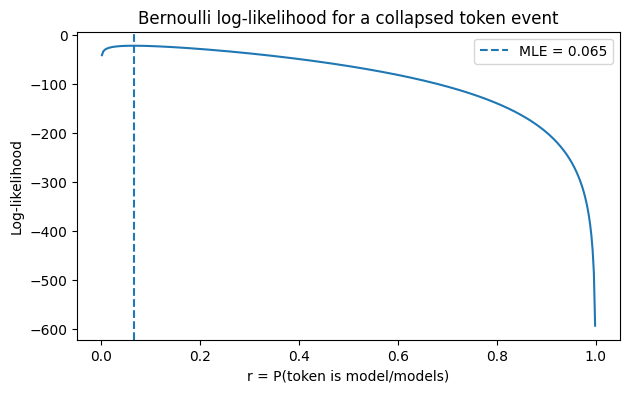

k: 6
n: 92
k/n: 0.06521739130434782


In [8]:
binary_obs = [1 if tok in {"model", "models"} else 0 for tok in tokens]
k = sum(binary_obs)
n = len(binary_obs)
r_hat = k / n

r_grid = np.linspace(0.001, 0.999, 400)
ll_grid = k * np.log(r_grid) + (n - k) * np.log(1 - r_grid)

plt.figure(figsize=(7, 4))
plt.plot(r_grid, ll_grid)
plt.axvline(r_hat, linestyle="--", label=f"MLE = {r_hat:.3f}")
plt.xlabel("r = P(token is model/models)")
plt.ylabel("Log-likelihood")
plt.title("Bernoulli log-likelihood for a collapsed token event")
plt.legend()
plt.show()

print("k:", k)
print("n:", n)
print("k/n:", r_hat)

## 8. Entropy: measuring uncertainty

For a probability distribution $p$ on a vocabulary, entropy is

$$
H(p)=-\sum_j p_j\log p_j.
$$

Entropy is small when probability mass is concentrated on a few outcomes. Entropy is large when probability mass is spread out.

In [9]:
def entropy(probs):
    # Entropy in nats for an iterable of probabilities.
    return -sum(p * math.log(p) for p in probs if p > 0)

sharp = [0.90, 0.05, 0.03, 0.02]
spread = [0.25, 0.25, 0.25, 0.25]
unigram_entropy = entropy(empirical_p.values())

print("Entropy of sharp distribution:", round(entropy(sharp), 4))
print("Entropy of spread distribution:", round(entropy(spread), 4))
print("Entropy of empirical unigram distribution:", round(unigram_entropy, 4))
print("Effective vocabulary size exp(H):", round(math.exp(unigram_entropy), 2))

Entropy of sharp distribution: 0.428
Entropy of spread distribution: 1.3863
Entropy of empirical unigram distribution: 3.9983
Effective vocabulary size exp(H): 54.5


The quantity $\exp(H(p))$ is sometimes called the effective number of choices. It answers the question:

> How many equally likely tokens would produce the same entropy?

## 9. Cross-entropy, KL divergence, and perplexity

Suppose $p$ is the data distribution and $q$ is a model distribution.

The cross-entropy from $p$ to $q$ is

$$
H(p,q)=-\sum_j p_j\log q_j.
$$

The KL divergence from $p$ to $q$ is

$$
D_{KL}(p||q)=\sum_j p_j\log\frac{p_j}{q_j}.
$$

They satisfy

$$
H(p,q)=H(p)+D_{KL}(p||q).
$$

For a language model, perplexity is

$$
\operatorname{PPL}=\exp(H(p,q))
$$

when cross-entropy is measured per token using natural logarithms.

In [10]:
def cross_entropy(p, q, support=None, epsilon=1e-15):
    # Cross-entropy H(p,q) for dictionaries of probabilities.
    if support is None:
        support = sorted(set(p) | set(q))
    total = 0.0
    for tok in support:
        p_tok = p.get(tok, 0.0)
        q_tok = max(q.get(tok, 0.0), epsilon)
        if p_tok > 0:
            total += -p_tok * math.log(q_tok)
    return total

def kl_divergence(p, q, support=None, epsilon=1e-15):
    # KL divergence D_KL(p || q) for dictionaries of probabilities.
    if support is None:
        support = sorted(set(p) | set(q))
    total = 0.0
    for tok in support:
        p_tok = p.get(tok, 0.0)
        q_tok = max(q.get(tok, 0.0), epsilon)
        if p_tok > 0:
            total += p_tok * math.log(p_tok / q_tok)
    return total

comparison_rows = []
for name, q in [("empirical MLE", empirical_q), ("uniform", uniform_q), ("hand-made", hand_q)]:
    H_pq = cross_entropy(empirical_p, q, vocab)
    KL = kl_divergence(empirical_p, q, vocab)
    comparison_rows.append({
        "model q": name,
        "H(p)": entropy(empirical_p.values()),
        "H(p,q)": H_pq,
        "D_KL(p||q)": KL,
        "H(p)+KL": entropy(empirical_p.values()) + KL,
        "perplexity exp(H(p,q))": math.exp(H_pq)
    })

pd.DataFrame(comparison_rows).sort_values("H(p,q)")

,model q,H(p),"H(p,q)",D_KL(p||q),H(p)+KL,"perplexity exp(H(p,q))"
0,empirical MLE,3.998282,3.998282,0.000000,3.998282,54.504434
2,hand-made,3.998282,4.086457,0.088175,4.086457,59.528589
1,uniform,3.998282,4.143135,0.144853,4.143135,63.000000


**Check the identity.** In the table above, the columns $H(p,q)$ and $H(p)+D_{KL}(p||q)$ should match up to numerical rounding.

## 10. Negative log-likelihood from observed tokens

If a model assigns probability $q(w_i)$ to observed token $w_i$, the negative log-likelihood is

$$
\operatorname{NLL}(q)=-\sum_{i=1}^N \log q(w_i).
$$

The average NLL is

$$
\frac{1}{N}\operatorname{NLL}(q).
$$

Perplexity is

$$
\exp\left(\frac{1}{N}\operatorname{NLL}(q)ight).
$$

In [11]:
observed = tokenize("language models estimate probability from data")

# A toy model distribution on just the needed tokens.
toy_model = {
    "language": 0.18,
    "models": 0.16,
    "estimate": 0.10,
    "probability": 0.20,
    "from": 0.12,
    "data": 0.24
}

nll = -sum(math.log(toy_model[tok]) for tok in observed)
avg_nll = nll / len(observed)
ppl = math.exp(avg_nll)

print("Observed tokens:", observed)
print("NLL:", round(nll, 4))
print("Average NLL:", round(avg_nll, 4))
print("Perplexity:", round(ppl, 4))

Observed tokens: ['language', 'models', 'estimate', 'probability', 'from', 'data']
NLL: 11.0068
Average NLL: 1.8345
Perplexity: 6.2618


## 11. Numerical stability: products versus logs

Products of many probabilities can become too small for floating-point arithmetic. Logs turn products into sums:

$$
\log \prod_{t=1}^T p_t=\sum_{t=1}^T \log p_t.
$$

In [12]:
small_probs = [0.02] * 400

product_prob = 1.0
for p in small_probs:
    product_prob *= p

log_prob = sum(math.log(p) for p in small_probs)

print("Product probability:", product_prob)
print("Log probability:", log_prob)
print("Average negative log probability:", -log_prob / len(small_probs))
print("Perplexity:", math.exp(-log_prob / len(small_probs)))

Product probability: 0.0
Log probability: -1564.8092021712584
Average negative log probability: 3.912023005428146
Perplexity: 49.99999999999999


The raw product underflows to a value that is essentially impossible to inspect. The log probability remains stable and meaningful.

## 12. Softmax and temperature

A neural language model often produces scores called logits. Softmax converts logits into probabilities:

$$
p_j=\frac{\exp(z_j)}{\sum_k \exp(z_k)}.
$$

With temperature $T>0$,

$$
p_j(T)=\frac{\exp(z_j/T)}{\sum_k \exp(z_k/T)}.
$$

- Smaller $T$ makes the distribution sharper.
- Larger $T$ makes the distribution flatter.
- The ranking of logits does not change, but uncertainty changes.

In [13]:
def softmax(logits, temperature=1.0):
    z = np.array(logits, dtype=float) / temperature
    z = z - z.max()  # numerical stability
    exp_z = np.exp(z)
    return exp_z / exp_z.sum()

candidate_tokens = ["predict", "learn", "generate", "classify", "fail", "the"]
logits = np.array([3.0, 2.3, 1.6, 1.2, 0.2, -0.4])

temp_rows = []
for T in [0.25, 0.5, 1.0, 1.5, 2.5]:
    probs = softmax(logits, temperature=T)
    temp_rows.append({
        "temperature": T,
        "entropy": entropy(probs),
        "effective_choices_exp_H": math.exp(entropy(probs)),
        "top_token": candidate_tokens[int(np.argmax(probs))],
        "top_probability": float(probs.max())
    })

pd.DataFrame(temp_rows)

,temperature,entropy,effective_choices_exp_H,top_token,top_probability
0,0.25,0.247708,1.281086,predict,0.938730
1,0.50,0.771709,2.163460,predict,0.746524
2,1.00,1.330691,3.783658,predict,0.499335
3,1.50,1.546487,4.694950,predict,0.387624
4,2.50,1.692802,5.434690,predict,0.294405


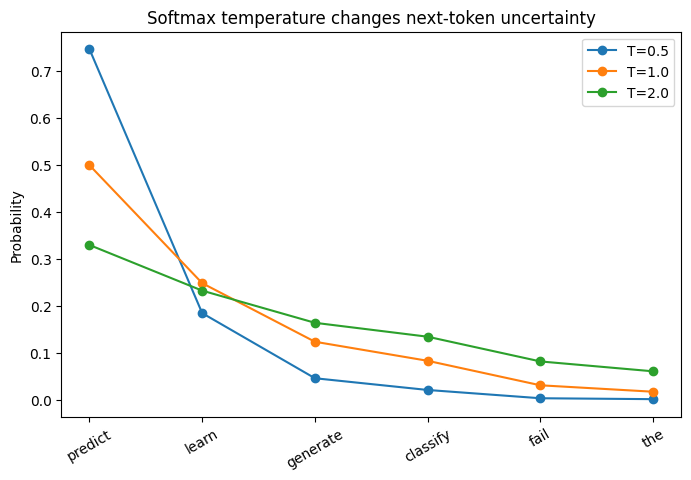

In [14]:
plt.figure(figsize=(8, 5))
for T in [0.5, 1.0, 2.0]:
    probs = softmax(logits, temperature=T)
    plt.plot(candidate_tokens, probs, marker="o", label=f"T={T}")
plt.ylabel("Probability")
plt.title("Softmax temperature changes next-token uncertainty")
plt.legend()
plt.xticks(rotation=30)
plt.show()

### Sampling from next-token probabilities

Generation often samples from a next-token distribution rather than always choosing the maximum-probability token.

In [15]:
for T in [0.5, 1.0, 2.0]:
    probs = softmax(logits, temperature=T)
    samples = rng.choice(candidate_tokens, size=12, replace=True, p=probs)
    print(f"T={T}:", " ".join(samples))

T=0.5: predict predict predict predict predict predict predict generate learn predict predict predict
T=1.0: classify predict classify predict predict predict generate classify predict predict generate learn
T=2.0: generate learn predict learn generate predict learn predict predict predict generate predict


**Try it yourself.** Change the logits or the temperature values. What happens to entropy and the sample diversity?

## 13. Conditional probability and bigram models

A bigram model uses the previous token as context. It estimates

$$
P(W_t=b \mid W_{t-1}=a).
$$

From counts,

$$
\widehat P(b\mid a)=\frac{c(a,b)}{c(a)},
$$

where $c(a,b)$ is the number of times token $a$ is followed by token $b$.

In [16]:
def add_boundaries(token_list):
    return ["<s>"] + token_list + ["</s>"]

bounded_docs = [add_boundaries(doc) for doc in tokenized_docs]

bigram_counts = defaultdict(Counter)
context_counts = Counter()

for doc in bounded_docs:
    for a, b in zip(doc[:-1], doc[1:]):
        bigram_counts[a][b] += 1
        context_counts[a] += 1

previous_token = "probability"
next_counts = bigram_counts[previous_token]
total_after = context_counts[previous_token]

bigram_table = pd.DataFrame({
    "next_token": sorted(next_counts),
    "count": [next_counts[t] for t in sorted(next_counts)],
    "P(next | previous)": [next_counts[t] / total_after for t in sorted(next_counts)]
})

print(f"Next-token distribution after '{previous_token}':")
bigram_table

Next-token distribution after 'probability':


,next_token,count,P(next | previous)
0,distribution,1,0.25
1,estimation,1,0.25
2,helps,1,0.25
3,to,1,0.25


Different contexts have different next-token distributions. Let us inspect several contexts.

In [17]:
def conditional_distribution(previous_token):
    total = context_counts[previous_token]
    if total == 0:
        return {}
    return {tok: count / total for tok, count in bigram_counts[previous_token].items()}

for prev in ["language", "models", "token", "entropy", "<s>"]:
    dist = conditional_distribution(prev)
    print(f"\nAfter {prev!r}:")
    for tok, prob in sorted(dist.items(), key=lambda x: (-x[1], x[0])):
        print(f"  {tok:15s} {prob:.3f}")


After 'language':
  </s>            0.333
  modeling        0.333
  models          0.333

After 'models':
  estimate        0.400
  assign          0.200
  describe        0.200
  represent       0.200

After 'token':
  </s>            0.200
  distribution    0.200
  from            0.200
  pairs           0.200
  sequences       0.200

After 'entropy':
  measures        1.000

After '<s>':
  language        0.167
  a               0.083
  bayesian        0.083
  bigram          0.083
  cross           0.083
  discriminative  0.083
  entropy         0.083
  generative      0.083
  perplexity      0.083
  probability     0.083
  smoothing       0.083


## 14. Zero probabilities and add-alpha smoothing

The unsmoothed bigram estimator assigns probability zero to unseen bigrams. But unseen does not mean impossible.

Add-alpha smoothing estimates

$$
\widehat P_\alpha(b\mid a)=\frac{c(a,b)+\alpha}{c(a)+\alpha d},
$$

where $d$ is the vocabulary size and $\alpha>0$.

In [18]:
bigram_vocab = sorted(set(tokens) | {"<s>", "</s>"})
D = len(bigram_vocab)

def bigram_prob(a, b, alpha=0.0):
    # Return P_alpha(b | a) using add-alpha smoothing.
    c_ab = bigram_counts[a][b]
    c_a = context_counts[a]
    if alpha == 0.0:
        if c_a == 0:
            return 0.0
        return c_ab / c_a
    return (c_ab + alpha) / (c_a + alpha * D)

pairs_to_check = [
    ("language", "models"),
    ("language", "banana"),
    ("probability", "distribution"),
    ("probability", "models"),
    ("unseen", "token")
]

rows = []
for a, b in pairs_to_check:
    rows.append({
        "previous": a,
        "next": b,
        "count(previous,next)": bigram_counts[a][b],
        "count(previous)": context_counts[a],
        "alpha=0": bigram_prob(a, b, alpha=0.0),
        "alpha=0.1": bigram_prob(a, b, alpha=0.1),
        "alpha=1": bigram_prob(a, b, alpha=1.0)
    })

pd.DataFrame(rows)

,previous,next,"count(previous,next)",count(previous),alpha=0,alpha=0.1,alpha=1
0,language,models,1,3,0.333333,0.115789,0.029412
1,language,banana,0,3,0.000000,0.010526,0.014706
2,probability,distribution,1,4,0.250000,0.104762,0.028986
3,probability,models,0,4,0.000000,0.009524,0.014493
4,unseen,token,1,1,1.000000,0.146667,0.030303


Smoothing gives positive probability to unseen events. However, it also lowers the probability assigned to observed events because total probability must still sum to one.

## 15. Sentence probability under a smoothed bigram model

For a tokenized sentence with boundaries,

$$
<s>,w_1,w_2,\ldots,w_T,</s>,
$$

the bigram model gives

$$
p(w_{1:T})=\prod_t p(w_t\mid w_{t-1}).
$$

We compute this in log space.

In [19]:
def sentence_log_probability(sentence, alpha=0.1):
    toks = add_boundaries(tokenize(sentence))
    logp = 0.0
    details = []
    for a, b in zip(toks[:-1], toks[1:]):
        p = bigram_prob(a, b, alpha=alpha)
        logp += math.log(p)
        details.append((a, b, p, math.log(p)))
    return logp, details

sentences_to_score = [
    "language models estimate probability",
    "probability models estimate language",
    "entropy measures uncertainty",
    "unseen words surprise models"
]

score_rows = []
for sentence in sentences_to_score:
    logp, details = sentence_log_probability(sentence, alpha=0.1)
    num_bigrams = len(details)
    score_rows.append({
        "sentence": sentence,
        "log_probability": logp,
        "avg_negative_log_probability": -logp / num_bigrams,
        "perplexity": math.exp(-logp / num_bigrams)
    })

pd.DataFrame(score_rows).sort_values("avg_negative_log_probability")

,sentence,log_probability,avg_negative_log_probability,perplexity
2,entropy measures uncertainty,-10.707997,2.676999,14.541391
0,language models estimate probability,-15.128836,3.025767,20.609812
1,probability models estimate language,-15.775463,3.155093,23.455211
3,unseen words surprise models,-22.631551,4.526310,92.416924


The absolute probabilities are not very meaningful in such a tiny corpus. The important skill is understanding how the chain rule, conditional probabilities, log probabilities, and smoothing work together.

## 16. Inspecting one sentence score

A sequence probability is a product of local conditional probabilities. Looking at the individual bigram factors helps us interpret the score.

In [20]:
sentence = "language models estimate probability"
logp, details = sentence_log_probability(sentence, alpha=0.1)

pd.DataFrame(details, columns=["previous", "next", "P(next | previous)", "log_probability"])

,previous,next,P(next | previous),log_probability
0,<s>,language,0.113514,-2.175833
1,language,models,0.115789,-2.155982
2,models,estimate,0.182609,-1.700410
3,estimate,probability,0.011765,-4.442651
4,probability,</s>,0.009524,-4.653960


## 17. Generative versus discriminative probability models

For a labeled text example, let $X$ be the text and $Y$ be the label.

A **generative** model describes a joint distribution:

$$
P(X,Y)=P(Y)P(X\mid Y).
$$

A **discriminative** model directly estimates

$$
P(Y\mid X).
$$

Naive Bayes is a generative classifier. Logistic regression and most neural classifiers are discriminative.

In this lab, we build a tiny generative classifier to preview the probabilistic structure of Chapter 6.

## 18. A tiny Bayesian text classifier

We use a small labeled corpus with two labels:

- `probability`: texts about probability, entropy, and likelihood;
- `geometry`: texts about vectors, cosine similarity, and embeddings.

The naive Bayes approximation says

$$
P(x_1,\ldots,x_m\mid Y=y)\approx \prod_{i=1}^m P(x_i\mid Y=y).
$$

Then Bayes' rule gives posterior class probabilities.

In [21]:
labeled_docs = [
    ("probability", "probability models uncertainty with distributions"),
    ("probability", "entropy and likelihood measure probabilistic surprise"),
    ("probability", "perplexity comes from average negative log likelihood"),
    ("probability", "bayesian models combine priors and likelihoods"),
    ("geometry", "document vectors represent text in coordinate space"),
    ("geometry", "cosine similarity compares the angle between vectors"),
    ("geometry", "embeddings place related words near each other"),
    ("geometry", "singular value decomposition reveals low dimensional structure")
]

labels = sorted(set(label for label, text in labeled_docs))
class_counts = Counter(label for label, text in labeled_docs)
class_token_counts = {label: Counter() for label in labels}
class_total_tokens = Counter()
nb_vocab = set()

for label, text in labeled_docs:
    toks = tokenize(text)
    class_token_counts[label].update(toks)
    class_total_tokens[label] += len(toks)
    nb_vocab.update(toks)

nb_vocab = sorted(nb_vocab)
print("Labels:", labels)
print("Vocabulary size:", len(nb_vocab))
print("Class document counts:", class_counts)

Labels: ['geometry', 'probability']
Vocabulary size: 48
Class document counts: Counter({'probability': 4, 'geometry': 4})


In [22]:
def class_log_prior(label):
    return math.log(class_counts[label] / len(labeled_docs))

def token_log_prob_given_class(token, label, alpha=1.0):
    # Laplace-smoothed log P(token | class).
    numerator = class_token_counts[label][token] + alpha
    denominator = class_total_tokens[label] + alpha * len(nb_vocab)
    return math.log(numerator / denominator)

def predict_naive_bayes(text, alpha=1.0):
    toks = tokenize(text)
    log_scores = {}
    for label in labels:
        score = class_log_prior(label)
        for tok in toks:
            score += token_log_prob_given_class(tok, label, alpha=alpha)
        log_scores[label] = score

    # Convert log scores to normalized posterior probabilities.
    max_log = max(log_scores.values())
    exp_scores = {label: math.exp(score - max_log) for label, score in log_scores.items()}
    total = sum(exp_scores.values())
    posterior = {label: val / total for label, val in exp_scores.items()}
    prediction = max(posterior, key=posterior.get)
    return prediction, posterior, log_scores

test_texts = [
    "entropy measures model uncertainty",
    "vectors and embeddings represent text",
    "likelihood compares probability models",
    "cosine similarity between document vectors"
]

rows = []
for text in test_texts:
    pred, posterior, log_scores = predict_naive_bayes(text, alpha=1.0)
    rows.append({
        "text": text,
        "P(probability | text)": posterior["probability"],
        "P(geometry | text)": posterior["geometry"],
        "prediction": pred
    })

pd.DataFrame(rows)

,text,P(probability | text),P(geometry | text),prediction
0,entropy measures model uncertainty,0.832376,0.167624,probability
1,vectors and embeddings represent text,0.140746,0.859254,geometry
2,likelihood compares probability models,0.917850,0.082150,probability
3,cosine similarity between document vectors,0.026575,0.973425,geometry


### Inspecting class-conditional token probabilities

Which words are most strongly associated with each class?

In [23]:
for label in labels:
    rows = []
    for tok in nb_vocab:
        prob = math.exp(token_log_prob_given_class(tok, label, alpha=1.0))
        rows.append((tok, prob))
    rows = sorted(rows, key=lambda x: x[1], reverse=True)[:10]
    print(f"\nTop smoothed token probabilities for class {label!r}:")
    for tok, prob in rows:
        print(f"  {tok:15s} {prob:.4f}")


Top smoothed token probabilities for class 'geometry':
  vectors         0.0395
  angle           0.0263
  between         0.0263
  compares        0.0263
  coordinate      0.0263
  cosine          0.0263
  decomposition   0.0263
  dimensional     0.0263
  document        0.0263
  each            0.0263

Top smoothed token probabilities for class 'probability':
  and             0.0417
  likelihood      0.0417
  models          0.0417
  average         0.0278
  bayesian        0.0278
  combine         0.0278
  comes           0.0278
  distributions   0.0278
  entropy         0.0278
  from            0.0278


**Try it yourself.** Add a third class such as `optimization` and retrain the tiny classifier.

## 19. A probability audit checklist

Probabilistic NLP models depend on assumptions. A careful audit asks:

1. What is the vocabulary?
2. What is the sample space?
3. What random variables are being modeled?
4. What distribution is empirical, and what distribution is a model?
5. Which independence or context assumptions are being made?
6. What happens to unseen events?
7. Which loss or metric is being optimized?
8. Does the evaluation data match the intended use case?

This checklist is useful for classical models, neural models, and large language models.

## 20. AI-assisted study activity

Use an AI assistant as a study partner, not as an authority.

### Prompt A: Explain conditional language modeling

```text
In mathematical terms, explain why a next-token language model estimates p_theta(w_t | w_1, ..., w_{t-1}). Distinguish the model distribution from the empirical distribution.
```

Check the answer:

- Does it say the output is a full distribution over the vocabulary?
- Does it distinguish $p_\theta$ from empirical frequencies?
- Does it avoid saying that the argmax token is the whole model?

### Prompt B: Critique perplexity

```text
Give three reasons why lower perplexity may not imply a better NLP system for a real application.
```

A strong answer should mention domain shift, task mismatch, factuality, robustness, or safety.

### Prompt C: Derive the unigram MLE

```text
Derive the maximum likelihood estimator for a unigram model using counts c_j and the constraint sum_j p_j = 1.
```

Verify the derivation by checking that the final answer is $c_j/N$.

## 21. Exercises

### Conceptual exercises

1. Explain the difference between an empirical distribution and a model distribution.
2. Why does a language model output a probability vector rather than only one token?
3. Give one context where next-token entropy should be high and one context where it should be low.
4. Why can a zero bigram probability be a problem for sentence scoring?
5. Why is average NLL more useful than raw likelihood when comparing corpora of different lengths?

### Mathematical exercises

6. Let $V=\{a,b,c\}$ and counts be $(10,5,5)$. Compute the unigram MLE.
7. Compute the entropy of $p=(1/2,1/4,1/4)$ using natural logarithms.
8. Let $p=(0.5,0.5)$ and $q=(0.9,0.1)$. Compute $H(p,q)$ and $D_{KL}(p||q)$.
9. A model assigns probabilities $0.5$, $0.25$, and $0.1$ to three observed next tokens. Compute total NLL, average NLL, and perplexity.
10. For logits $(3,1,0)$, compute the softmax probabilities numerically.

### Python exercises

11. Write a function that returns the empirical distribution of a token list.
12. Write a function that computes entropy for a probability vector.
13. Write a function that computes cross-entropy between two probability dictionaries.
14. Build a bigram table from five sentences of your choice.
15. Modify the smoothed bigram code and compare $\alpha=0.01$, $\alpha=0.1$, and $\alpha=1$.

## 22. Mini-project: probabilistic language audit

Choose a small corpus of 20 to 50 short texts. Possible sources include course descriptions, article titles, news headlines, or abstracts.

Create a short probability audit with the following parts:

1. Tokenize the corpus and construct the vocabulary.
2. Compute empirical unigram probabilities.
3. Plot the top 20 token probabilities.
4. Compute the unigram entropy and effective vocabulary size $\exp(H)$.
5. Build bigram counts and inspect next-token distributions after five selected tokens.
6. Compare unsmoothed and smoothed probabilities for at least five bigrams.
7. Score at least five short sentences using a smoothed bigram model.
8. Write one paragraph explaining what your model captures.
9. Write one paragraph explaining what your model misses.

Your final report should include at least one table, one plot, and a short written interpretation.

## 23. Lab summary

In this lab, you learned how to treat language as probabilistic data.

Key ideas:

- A token can be modeled as a random variable over a vocabulary.
- Counts become empirical probabilities by normalization.
- The unigram MLE is the empirical token distribution.
- Log-likelihood is more stable than raw likelihood.
- Entropy measures uncertainty.
- Cross-entropy and KL divergence compare data and model distributions.
- Perplexity is exponentiated average negative log-likelihood.
- A bigram model estimates conditional next-token probabilities.
- Smoothing prevents unseen events from receiving zero probability.
- Bayesian text classification combines priors, likelihoods, and normalization.

These tools prepare you for n-gram language models, Naive Bayes text classification, and neural language modeling.